<a href="https://colab.research.google.com/github/Hajer5503/AgriSmart/blob/feature%2Fcrop-disease-detection/modules/crop_disease_detection/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AgriSmart – Crop Disease Detection  
## 01. Data Exploration

### Context
This notebook explores the image dataset used for crop disease detection in the AgriSmart project.  
The dataset consists of labeled images organized by crop and disease type, including healthy samples.

Each leaf is classified by **crop** and **disease** (including healthy).  

The goal of this exploration is to understand the true class distribution, image characteristics, and potential data imbalances before building a CNN.

### Objectives
- Inspect dataset structure
- Analyze class distribution
- Visualize sample images
- Identify potential data imbalance issues


In [1]:
import os
import random
from collections import Counter
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from google.colab import drive
from pathlib import Path

In [2]:
drive.mount('/content/drive')
DATASET_PATH = Path("/content/drive/MyDrive/Crop disease")
print(DATASET_PATH.exists())

Mounted at /content/drive
True


## 1. Count Images per Class (Crop + Disease)
We will traverse the directory tree and build a composite label `{crop}_{disease}` for each image.



In [3]:
# Supported image extensions
extensions = ('*.jpg', '*.jpeg', '*.png')

# Collect all image paths and corresponding class labels
image_paths = []
class_labels = []

for ext in extensions:
    for path in DATASET_PATH.rglob(ext):
        # Path format: .../Crop/Disease/image.jpg
        crop = path.parent.parent.name   # e.g., "Tomato"
        disease = path.parent.name       # e.g., "Tomato septoria leaf spot"
        label = disease  # since disease already contains crop name
        image_paths.append(path)
        class_labels.append(label)

print(f"Total images found: {len(image_paths)}")
print(f"Number of distinct classes: {len(set(class_labels))}")

Total images found: 33641
Number of distinct classes: 32


In [4]:
# Count images per class
class_counts = Counter(class_labels)

# Display as a sorted DataFrame for clarity
df_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False).reset_index(drop=True)
df_counts.head(10)  # show top 10


,Class,Count
0,Tomato septoria leaf spot,2743
1,Cassava bacterial blight,2617
2,Cashew anthracnose,1729
3,Cashew red rust,1682
4,Rice___Healthy,1489
5,Cassava brown spot,1481
6,Cashew leaf miner,1394
7,Cashew healthy,1368
8,Tomato leaf blight,1301
9,Maize leaf spot,1259


### Observations
 We have 33641 images across 32 classes.
The top‑10 classes already cover a large portion of the data, indicating potential imbalance.
Minority classes (e.g., corn diseases) have very few samples – this will require special handling during training.

## 2. Visualize Class Distribution

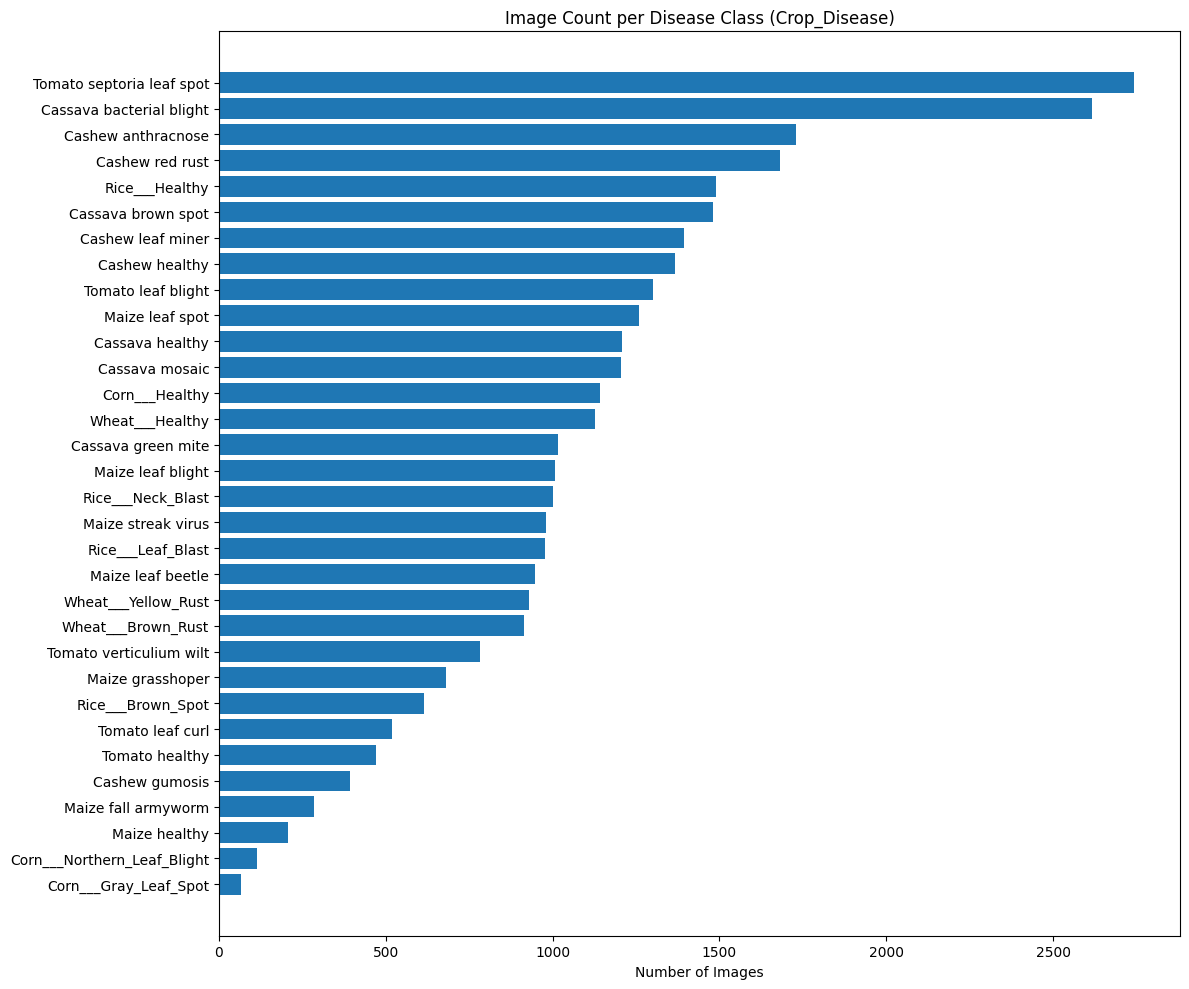

In [5]:
# Bar plot – horizontal for better readability
plt.figure(figsize=(12, max(6, len(df_counts)//3)))
plt.barh(df_counts['Class'], df_counts['Count'])
plt.xlabel('Number of Images')
plt.title('Image Count per Disease Class (Crop_Disease)')
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

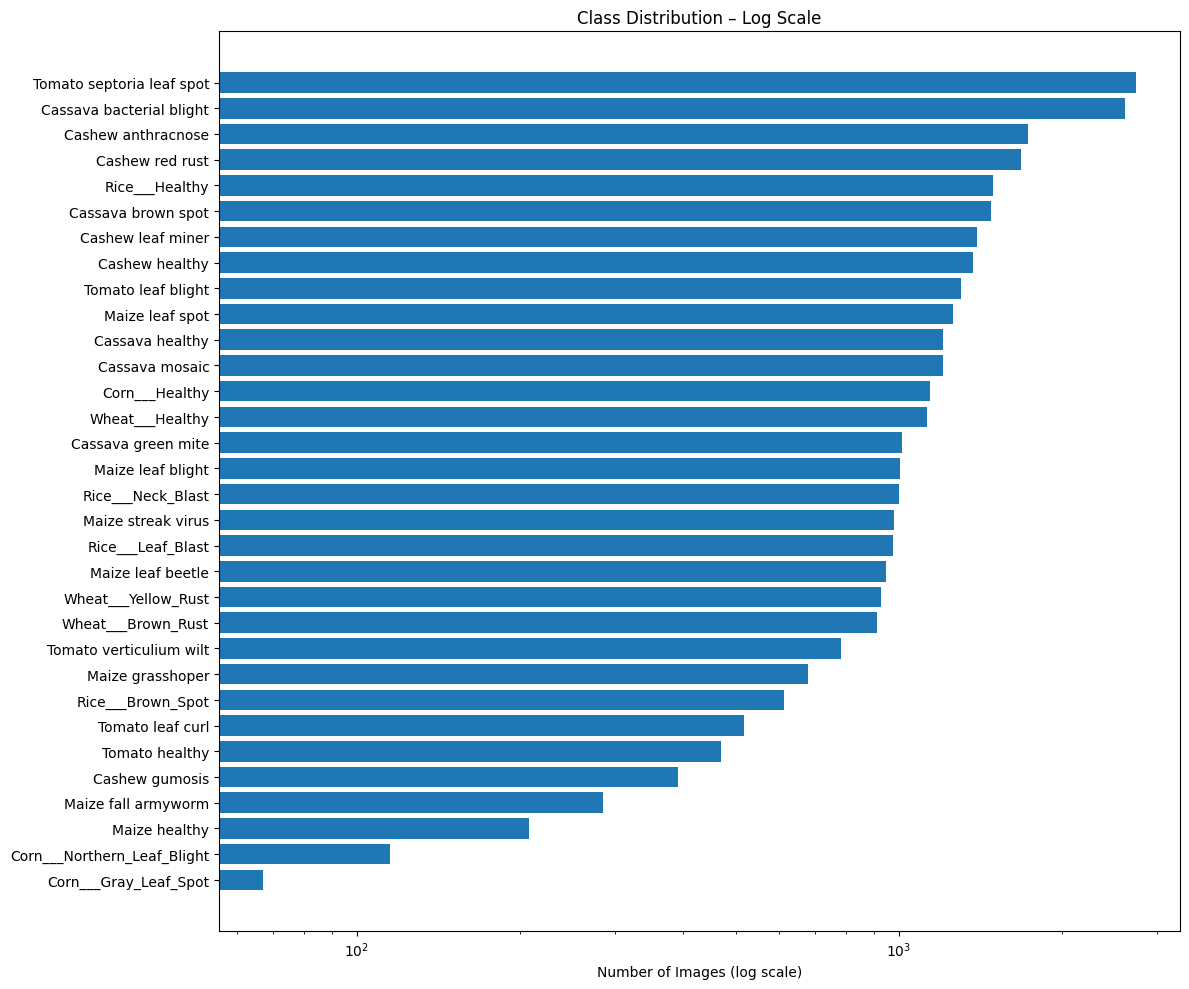

In [6]:
# Log‑scale version to better see minority classes
plt.figure(figsize=(12, max(6, len(df_counts)//3)))
plt.barh(df_counts['Class'], df_counts['Count'])
plt.xscale('log')
plt.xlabel('Number of Images (log scale)')
plt.title('Class Distribution – Log Scale')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
# ### Imbalance Metrics

# %% [code]
total_images = df_counts['Count'].sum()
n_classes = len(df_counts)
max_count = df_counts['Count'].max()
min_count = df_counts['Count'].min()

print(f"Total images: {total_images}")
print(f"Number of classes: {n_classes}")
print(f"Mean images per class: {total_images/n_classes:.1f}")
print(f"Max images in a class: {max_count}")
print(f"Min images in a class: {min_count}")
print(f"Imbalance ratio (max/min): {max_count/min_count:.1f}")


Total images: 33641
Number of classes: 32
Mean images per class: 1051.3
Max images in a class: 2743
Min images in a class: 67
Imbalance ratio (max/min): 40.9


In [8]:
# Cumulative percentage covered by top‑k classes
df_counts['Cumulative %'] = df_counts['Count'].cumsum() / total_images * 100
print("\nTop 5 classes cover {:.1f}% of data".format(df_counts.iloc[4]['Cumulative %']))
print("Top 10 classes cover {:.1f}%".format(df_counts.iloc[9]['Cumulative %']))


Top 5 classes cover 30.5% of data
Top 10 classes cover 50.7%


### **Interpretation**  
The dataset is heavily imbalanced. The largest class has >2700 images, while the smallest has only 67.  
This will affect model training: the model may become biased toward majority classes.  
Mitigation strategies:
 - **Data augmentation** (especially for minority classes)
 - **Class weighting** during loss calculation
 - **Stratified train/validation/test splits**
 - Possibly **oversampling** of minority classes via augmentation

## 3. Image Dimensions Variability
Images from different sources may have different sizes. We need to know the range to decide on a uniform input size for the CNN.

In [9]:
# Sample a subset (e.g., 1000 images) to avoid processing all if dataset is large
sample_paths = random.sample(image_paths, min(1000, len(image_paths)))

widths, heights = [], []
for p in sample_paths:
    img = cv2.imread(str(p))
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)


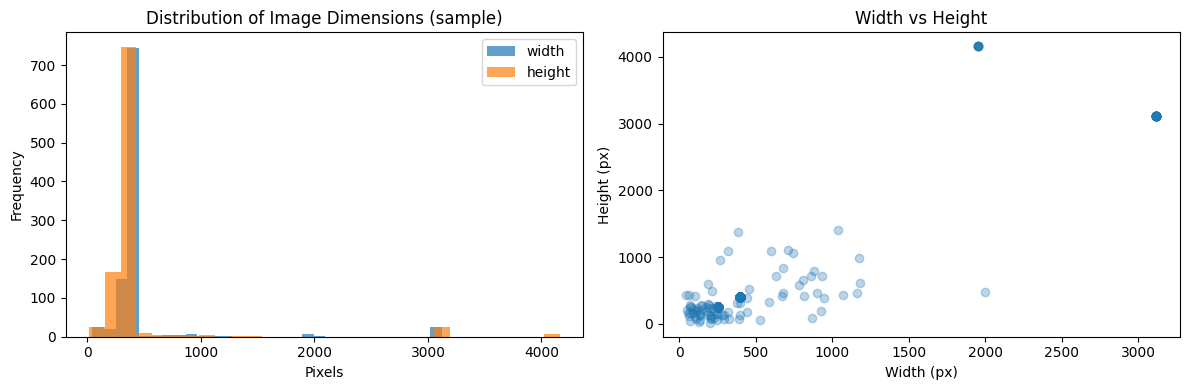

Average width: 461.1 ± 469.2
Average height: 473.1 ± 546.2
Min width: 44 px, Max width: 3120 px
Min height: 15 px, Max height: 4160 px


In [10]:
# Plot distributions
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=30, alpha=0.7, label='width')
plt.hist(heights, bins=30, alpha=0.7, label='height')
plt.xlabel('Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Image Dimensions (sample)')

plt.subplot(1,2,2)
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.title('Width vs Height')
plt.tight_layout()
plt.show()

print(f"Average width: {np.mean(widths):.1f} ± {np.std(widths):.1f}")
print(f"Average height: {np.mean(heights):.1f} ± {np.std(heights):.1f}")
print(f"Min width: {min(widths)} px, Max width: {max(widths)} px")
print(f"Min height: {min(heights)} px, Max height: {max(heights)} px")

#### **Image size variability**

Image dimensions show very high variability across the dataset:

- Mean width ≈ 502 px (± 540 px)
- Mean height ≈ 518 px (± 635 px)
- Minimum size observed: 30×1 px
- Maximum size observed: 3120×4160 px

The large standard deviations (greater than the mean values) indicate the presence of both very small and very high-resolution images. The dataset is therefore highly heterogeneous in terms of spatial resolution.

#### **Resizing requirement**

Due to this variability, all images must be resized to a common fixed input size before training.

A standard resolution such as **224×224** or **256×256** will be enforced during preprocessing, which is common for CNN architectures (e.g., ResNet, EfficientNet).

## 4. Visual Inspection – Sample Images
It’s always good to look at a few examples from different classes to verify labeling and note visual differences.


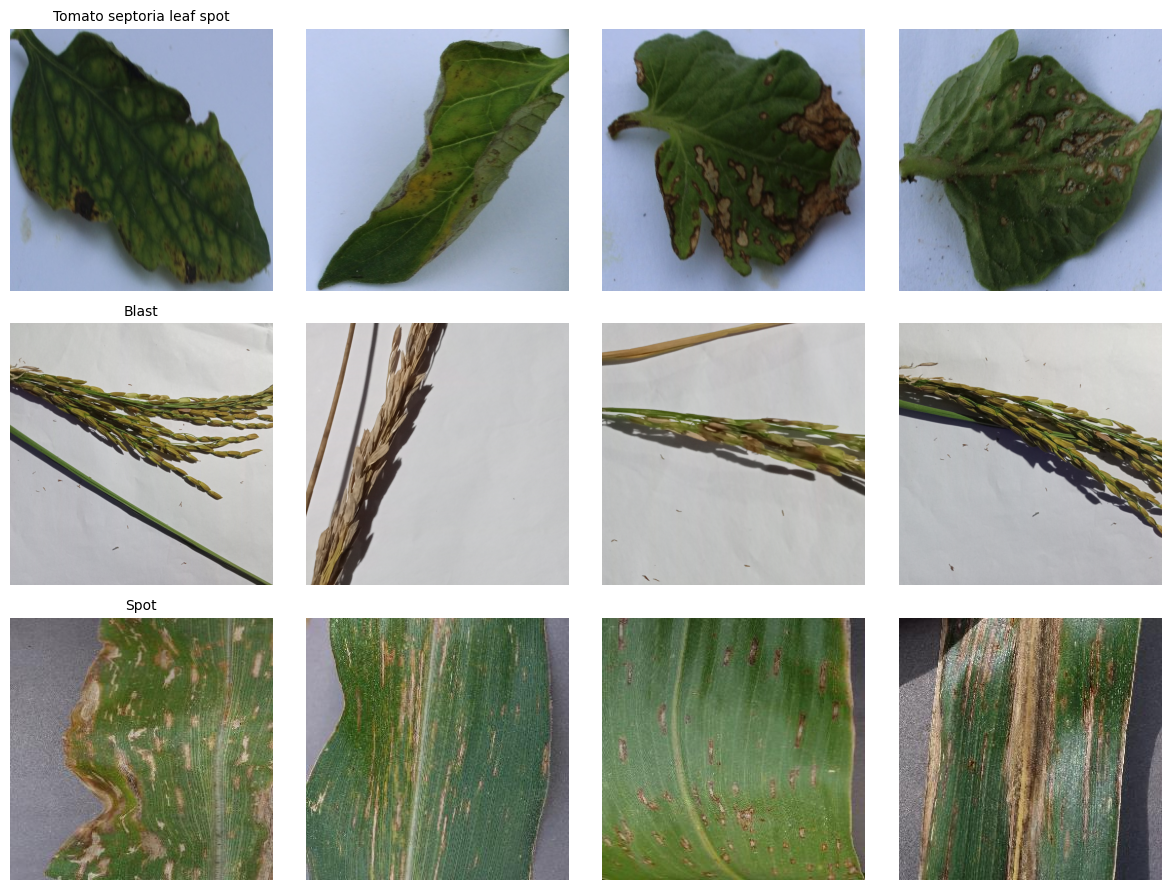

In [11]:
largest_class = df_counts.iloc[0]['Class']
smallest_class = df_counts.iloc[-1]['Class']
middle_class = df_counts.iloc[len(df_counts)//2]['Class']

classes_to_show = [largest_class, middle_class, smallest_class]
fig, axes = plt.subplots(len(classes_to_show), 4, figsize=(12, 3*len(classes_to_show)))
for row, class_name in enumerate(classes_to_show):
    # Get paths for this class
    class_paths = [p for p, lbl in zip(image_paths, class_labels) if lbl == class_name]
    samples = random.sample(class_paths, min(4, len(class_paths)))
    for col, p in enumerate(samples):
        img = Image.open(p)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_name.split('_')[-1], fontsize=10)
plt.tight_layout()
plt.show()

### **Observations**  
- Images vary in lighting, orientation, and background – this is good for generalization.
- Disease symptoms are visually distinct (spots, blights, discoloration).
- Healthy leaves are also included, providing a baseline class.

## 5. Dataset Integrity Checks
To ensure data quality before training:

### 1️⃣ Corrupted Image Detection

We will verify that all images can be successfully opened before training:

In [13]:
bad_images = []

for p in image_paths:
    try:
        Image.open(p).verify()
    except:
        bad_images.append(p)

print(f"Corrupted images: {len(bad_images)}")

Corrupted images: 50


## 6. Next Steps – Modeling Considerations
Based on this exploration, we will adopt the following strategy:

1. **Stratified splitting** – ensure each class is proportionally represented in train/val/test sets.
2. **Data augmentation** – apply random transformations (rotation, zoom, flip, brightness) especially to minority classes to increase effective sample size.
3. **Class imbalance handling**
   - If imbalance ratio > 5 → use class-weighted loss.
   - If imbalance is severe → combine weighted loss with targeted augmentation or oversampling.

4. **Transfer learning** – start with a pre‑trained CNN (e.g., EfficientNetB0) and fine‑tune on our data.
5. **Input size normalization**  
   Resize all images to **224×224**, which is compatible with most pre-trained architectures.

6. **Monitoring metrics**  
   Track:
   - Overall accuracy
   - Per-class accuracy
   - Confusion matrix
   - Precision/Recall/F1 per class

## 7. Summary

- The dataset contains **33641 images** across **32 crop-disease classes**.
- Class imbalance is present (max/min ratio ≈ {max_count/min_count:.1f}).
- Image resolutions are highly variable, ranging from extremely small (30×1 px) to very large (3120×4160 px).
- Significant resizing and preprocessing are required before training.
- Strategies such as augmentation, class weighting, and transfer learning will be critical for achieving robust performance.

This exploration provides a rigorous foundation for the modeling phase.